# Agent Economics Lab: demo

This notebook runs the three results end to end: the efficiency and supplier-share sweep, the LLM truthfulness probe, and the house-extraction harness. Everything here is deterministic and offline. The truthfulness probe replays saved Claude bids from `results/truthfulness_raw.json`, so it needs no API key.

## Setup

Load the default scenario. Every number below is reproducible from a scenario file plus the saved response cache.

In [1]:
from pathlib import Path

from IPython.display import Image

from aelab.cli import run_attacks, run_efficiency, run_probe
from aelab.config import load_scenario

scenario = load_scenario("default")
scenario.name, scenario.seed

('default', 11)

## 1. Efficiency and the supplier-share curve

Under truthful bidding the lowest-cost funder always wins, so allocative efficiency is 1.000 at every financier count. The sweep holds suppliers and invoices fixed and grows only the financier pool, so the rising supplier share is competition at work, not a shifting population. Efficiency is necessary but not sufficient: a fully efficient market can still split the pie against the supplier, which is why supplier share is a first-class metric. The chart is saved to `results/efficiency.png`.

financiers  efficiency  supplier share
         1       1.000           0.885
         2       1.000           0.885
         3       1.000           0.885
         4       1.000           0.885
         6       1.000           0.902
         8       1.000           0.912
        12       1.000           0.917

Saved plot to results/efficiency.png


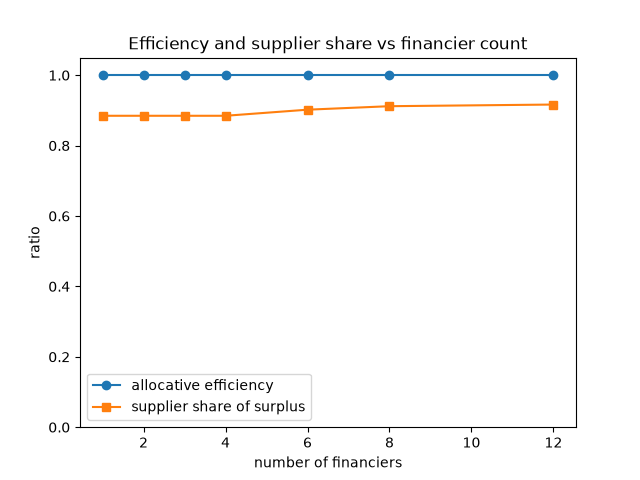

In [2]:
run_efficiency(scenario)
Image("results/efficiency.png")

## 2. Do LLM agents bid the dominant strategy?

This replays 120 saved Claude Haiku bids and measures each bid minus the funder's true cost. The deviation is about zero, so the agent does not overbid the way humans famously do in Vickrey experiments. Caveat to carry into the reading: the probe's system prompt states that truthful bidding is optimal, so this may be prompt-following rather than strategic reasoning (the discriminating test is in the closing note). The chart is saved to `results/truthfulness.png`.

Parsing saved raw results from results/truthfulness_raw.json (no live batch)

bids parsed:             120
parse failures:          0
missing from batch:      0
mean signed deviation:   -0.00000 APR
mean absolute deviation: 0.00002 APR
within 0.005 of truthful:  100.0%

Saved histogram to results/truthfulness.png


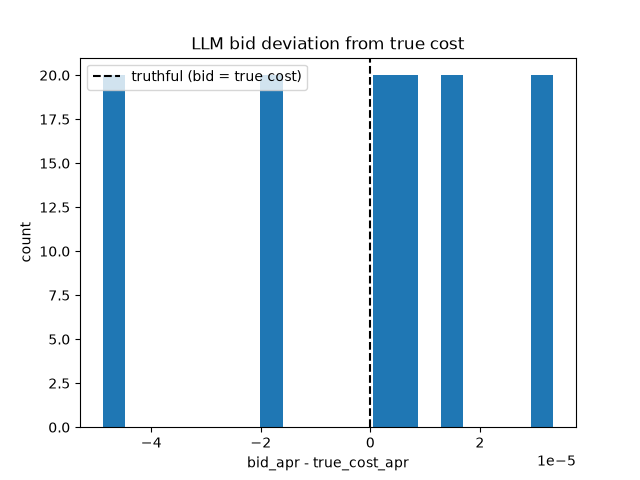

In [3]:
run_probe(scenario, Path("results/truthfulness_raw.json"))
Image("results/truthfulness.png")

## 3. House extraction, and a fair-rate index that catches it

The extraction scenario puts the house where the attack is measurable: a cheap in-house buyer wins every invoice, and the house is the pivotal second-lowest bid, posting its honest cost. The informed house peeks at sealed bids, cannot beat the buyer, and so withholds just under the reserve; the clearing jumps from the house cost to a financier's, supplier share drops from the separated benchmark, and the fair-rate index flags every extracted invoice. Efficiency stays 1.000 throughout: the buyer still wins, so the loss is on price, not allocation.

In [4]:
run_attacks(load_scenario("extraction"))

regime        efficiency  supplier_share  index_flags
baseline           1.000           0.754            0
separated          1.000           0.855            0
informed           1.000           0.754           50
collusion          1.000           0.754            0


### Competition disciplines it

The default scenario is the counterweight: a cheap buyer and competitive financiers sit below the house, so withholding the house changes nothing and the ring cannot lift a price the buyer holds down. Every regime lands on the same supplier share and the index stays quiet, which is the point: the defense against venue extraction is a market the house cannot pivot, not a rule that forbids it.

In [5]:
run_attacks(scenario)

regime        efficiency  supplier_share  index_flags
baseline           1.000           0.902            0
separated          1.000           0.902            0
informed           1.000           0.902            1
collusion          1.000           0.902            0


## What is missing: the first-price counterfactual

The truthfulness result above cannot separate reasoning from coaching on its own, because the prompt names the truthful strategy. The discriminating test is the same agents under a first-price reverse auction with a neutral prompt that states the rules but recommends no strategy: a reasoner shades its bid up to earn margin (truthful is no longer optimal), a prompt-follower stays near truthful in both auctions. That experiment is designed but not yet built or run, and it needs a live API key, so it is deliberately absent here rather than faked.